In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')


from spiking_model_utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E0A1B1_251107"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

with h5py.File(filepath, 'r') as f:
    print(f.keys())
    print(f['sessions'][0,0])

<KeysViewHDF5 ['#refs#', 'animals', 'sessions']>
<HDF5 object reference>


In [ ]:
import h5py, os
import numpy as np

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E0A1B1_251107"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

with h5py.File(filepath, 'r') as f:
    sessions = f['sessions']
    print("sessions shape:", sessions.shape, "dtype:", sessions.dtype)

    ref = sessions[0, 0]
    sess_ds = f[ref]   # this is a Dataset, not a Group
    print("sess_ds:", sess_ds)
    print("  shape:", sess_ds.shape)
    print("  dtype:", sess_ds.dtype)
    print("  dtype.names:", sess_ds.dtype.names)

    # grab the single record (usually shape (1,1) or (1,))
    idx = (0,) * len(sess_ds.shape)   # (0,0) if 2D, (0,) if 1D
    rec0 = sess_ds[idx]
    print("\nFirst record:", rec0)

    # print each field
    if sess_ds.dtype.names is not None:
        for name in sess_ds.dtype.names:
            value = rec0[name]
            print(f"  field '{name}':", value, " (shape:", getattr(value, 'shape', None), ")")



sessions shape: (2, 42) dtype: object
sess_ds: <HDF5 dataset "Dh": shape (12, 1), type "<u2">
  shape: (12, 1)
  dtype: uint16
  dtype.names: None

First record: 67


In [ ]:
import h5py, os
import numpy as np

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E0A1B1_251107"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

with h5py.File(filepath, 'r') as f:
    sessions = f['sessions']
    ref = sessions[0, 0]
    sess_ds = f[ref]           # (12, 1) uint16

    arr = sess_ds[...]         # shape (12, 1)
    codes = arr.flatten()      # shape (12,)
    # ignore zeros if any
    codes = codes[codes != 0]

    s = ''.join(chr(c) for c in codes)
    print("decoded session[0,0] string:", repr(s))


decoded session[0,0] string: 'CG186_250123'


In [ ]:
import h5py
import numpy as np
import os

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E1A1B"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

def decode_hdf5_string_dataset(ds):
    """Decode a MATLAB-style uint16 char dataset into a Python string."""
    arr = ds[...].flatten()
    arr = arr[arr != 0]      # drop any zero padding
    return ''.join(chr(c) for c in arr)

with h5py.File(filepath, 'r') as f:
    print(f.keys())
    sessions = f['sessions']
    n_rows, n_cols = sessions.shape

    session_strings = np.empty((n_rows, n_cols), dtype=object)

    for i in range(n_rows):
        for j in range(n_cols):
            ref = sessions[i, j]
            ds = f[ref]                      # e.g. /#refs#/Dh
            session_strings[i, j] = decode_hdf5_string_dataset(ds)

print(session_strings.shape)
# print(session_strings[0, :5])   # first 5 sessions in row 0
# print(session_strings[1, :5])   # first 5 sessions in row 1

print(session_strings)


<KeysViewHDF5 ['#refs#', '#subsystem#', 'animal', 'exptlist']>


KeyError: "Unable to synchronously open object (object 'sessions' doesn't exist)"

In [ ]:
import h5py
import numpy as np
import os

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E1A1B"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

def decode_hdf5_string_dataset(ds):
    arr = ds[...].flatten()
    arr = arr[arr != 0]
    return ''.join(chr(int(c)) for c in arr)

with h5py.File(filepath, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    exptlist = f['exptlist']
    refs_group = f['#refs#']

    print("exptlist shape:", exptlist.shape, "dtype:", exptlist.dtype)

    # keys inside '#refs#' – MATLAB usually stores all the cell contents here
    ref_keys = sorted(refs_group.keys())
    print("Number of entries in #refs#:", len(ref_keys))
    # optional: print first few keys to see the pattern
    print("First few #refs# keys:", ref_keys[:10])

    n_rows, n_cols = exptlist.shape
    print("exptlist rows, cols:", n_rows, n_cols)

    decoded = np.empty((n_rows, n_cols), dtype=object)

    for i in range(n_rows):
        for j in range(n_cols):
            idx = int(exptlist[i, j])        # uint32 index
            # assume exptlist indices are 0-based into sorted ref_keys
            ds_name = ref_keys[idx]
            ds = refs_group[ds_name]
            decoded[i, j] = decode_hdf5_string_dataset(ds)

    print("Decoded exptlist:")
    print(decoded)


Top-level keys: ['#refs#', '#subsystem#', 'animal', 'exptlist']
exptlist shape: (1, 6) dtype: uint32
Number of entries in #refs#: 595
First few #refs# keys: ['0', '0b', '0c', '0d', '0e', '0f', '0g', '0h', '0i', '1']
exptlist rows, cols: 1 6


IndexError: list index out of range

In [5]:
import os
import re
import h5py
import numpy as np

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E1A1B"
filepath = os.path.join(file_path, "datasets", filename + ".mat")


with h5py.File(filepath, 'r') as f:
    print(f['exptlist'][0,0])


3707764736


In [7]:
import mat73

with h5py.File(filepath, 'r') as f:
    expt = f['exptlist']

session_strings = []
for entry in expt:
    # each entry is a dict representing the MATLAB class
    if isinstance(entry, dict):
        # look for any field that contains the session name
        for k,v in entry.items():
            if isinstance(v, str) and "_" in v:
                session_strings.append(v)

print(session_strings)


RuntimeError: Unable to synchronously get dataspace (identifier is not of specified type)

In [8]:
import mat73
import os

filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E1A1B.mat'

# Only load the exptlist variable
data = mat73.loadmat(filepath, variable_names=['exptlist'])

expt = data['exptlist']   # list of 39 dicts

session_strings = []
for entry in expt:
    # each MCOS object becomes a Python dict
    for k, v in entry.items():
        if isinstance(v, str) and "_" in v:
            session_strings.append(v)

print("Found sessions:")
for s in session_strings:
    print(s)


TypeError: loadmat() got an unexpected keyword argument 'variable_names'

In [9]:
import mat73
import os
import re

filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E1A1B.mat'

# Load the file (slow only if we expand everything — so we won't)
print("Loading top-level mat file...")
data = mat73.loadmat(filepath)

# exptlist is a list of MCOS object dicts
exptlist = data.get('exptlist', None)
if exptlist is None:
    raise KeyError("No 'exptlist' variable found in MAT file!")

print("exptlist length:", len(exptlist))

session_pattern = re.compile(r"^[A-Za-z]{2}\d{3}_\d{6}$")
session_strings = []

for i, entry in enumerate(exptlist):
    if isinstance(entry, dict):
        # inspect only top-level fields inside each MCOS object
        for k, v in entry.items():
            # Many fields are strings: session name, animal name, date, fileBase, etc.
            if isinstance(v, str) and session_pattern.match(v):
                print(f"Session {i}: {v}")
                session_strings.append(v)

print("\nAll extracted session strings:")
print(session_strings)


Loading top-level mat file...


KeyboardInterrupt: 

In [12]:
import h5py
import numpy as np
import re

SESSION_PATTERN = re.compile(r'^[A-Za-z]{2}\d{3}_\d{6}$')  # e.g., CG189_250211


def decode_uint16_chars(arr):
    """Decode MATLAB-style uint16 char arrays."""
    arr = arr.flatten()
    arr = arr[arr != 0]
    return ''.join(chr(int(c)) for c in arr)


def scrape_mcos_for_session_strings(filepath):

    with h5py.File(filepath, "r") as f:

        # 1. Locate MCOS dataset
        try:
            mcos_ds = f["#subsystem#"]["MCOS"]
        except KeyError:
            raise RuntimeError("MCOS dataset not found.")

        if not isinstance(mcos_ds, h5py.Dataset):
            raise RuntimeError("Expected MCOS to be a dataset, but it's a group.")

        session_strings = set()

        # 2. Iterate through MCOS dataset entries
        mcos_entries = mcos_ds[()]   # read whole dataset

        for ref in mcos_entries.flatten():

            # Many entries may be empty or 0
            if not isinstance(ref, h5py.h5r.Reference):
                continue
            if not f.__contains__(ref):
                continue

            obj = f[ref]  # follow reference → likely a Group

            # 3. Inside each MCOS object, search for uint16 string datasets
            if isinstance(obj, h5py.Group):
                for key in obj.keys():
                    ds = obj[key]
                    if isinstance(ds, h5py.Dataset):

                        arr = ds[()]
                        # Only uint16 character arrays are relevant
                        if isinstance(arr, np.ndarray) and arr.dtype == np.uint16:
                            try:
                                s = decode_uint16_chars(arr)
                                if SESSION_PATTERN.match(s):
                                    session_strings.add(s)
                            except:
                                pass

        return sorted(session_strings)
file_path = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E1A1B.mat"
session_strings = scrape_mcos_for_session_strings(file_path)

print(len(session_strings))
print("\n".join(session_strings))


TypeError: A name should be string or bytes, not <class 'h5py.h5r.Reference'>

In [ ]:
import os
import re
import h5py
import numpy as np

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E1A1B"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

# pattern for session names like 'CG186_250123'
SESSION_PATTERN = re.compile(r'^[A-Za-z]{2}\d{3}_\d{6}$')

def decode_uint16_char_array(arr):
    """
    Decode a MATLAB-style uint16 char array → Python string.
    """
    flat = arr.flatten()
    flat = flat[flat != 0]
    return ''.join(chr(int(c)) for c in flat)


def find_session_string_in_group(node, f):
    """
    Recursively search within a group (or dataset) for a string
    that looks like 'CG186_250123'. Returns first match or None.
    """
    # If it's a dataset, try to decode if integer type
    if isinstance(node, h5py.Dataset):
        arr = node[()]
        if np.issubdtype(arr.dtype, np.integer):
            s = decode_uint16_char_array(arr)
            if SESSION_PATTERN.match(s):
                return s
        return None

    # If it's a group, recurse into children
    if isinstance(node, h5py.Group):
        for key in node.keys():
            child = node[key]
            s = find_session_string_in_group(child, f)
            if s is not None:
                return s

    return None


def get_session_strings_from_animal(filepath, entry_dataset='datasetZ'):
    """
    For the old NDNF_E1A1B.mat:
      - animal/<entry_dataset> is a (39,1) object array (cell array)
      - Each element is a reference to a per-session struct/group.
      - We walk each and look for a string like 'CG186_250123'.

    Returns:
      session_strings: list of length n_sessions (may contain None if no match)
    """
    session_strings = []

    with h5py.File(filepath, 'r') as f:
        animal = f['animal']
        ds = animal[entry_dataset]  # e.g. 'datasetZ' or 'wsALL'
        print(f"{entry_dataset} shape:", ds.shape, "dtype:", ds.dtype)

        n_rows, n_cols = ds.shape
        # you saw n_rows = 39, n_cols = 1
        for i in range(n_rows):
            ref = ds[i, 0]
            # old MATLAB files often store object references here
            if isinstance(ref, h5py.Reference):
                sess_node = f[ref]
                s = find_session_string_in_group(sess_node, f)
                session_strings.append(s)
                print(f"Session {i}: {s}")
            else:
                session_strings.append(None)
                print(f"Session {i}: not a Reference, got {type(ref)}")

    return session_strings


# --- run it ---
session_strings = get_session_strings_from_animal(filepath, entry_dataset='datasetZ')

print("\nAll session-like strings (by index):")
for i, s in enumerate(session_strings):
    print(f"{i:2d}: {s}")

# Derive animal IDs (prefix before '_') from the ones we found
animal_ids = sorted({s.split('_')[0] for s in session_strings if s is not None})
print("\nUnique animal IDs:")
print(animal_ids)


datasetZ shape: (39, 1) dtype: object
Session 0: None
Session 1: None
Session 2: None
Session 3: None
Session 4: None
Session 5: None
Session 6: None
Session 7: None
Session 8: None
Session 9: None
Session 10: None
Session 11: None
Session 12: None
Session 13: None
Session 14: None
Session 15: None
Session 16: None
Session 17: None
Session 18: None
Session 19: None
Session 20: None
Session 21: None
Session 22: None
Session 23: None
Session 24: None
Session 25: None
Session 26: None
Session 27: None
Session 28: None
Session 29: None
Session 30: None
Session 31: None
Session 32: None
Session 33: None
Session 34: None
Session 35: None
Session 36: None
Session 37: None
Session 38: None

All session-like strings (by index):
 0: None
 1: None
 2: None
 3: None
 4: None
 5: None
 6: None
 7: None
 8: None
 9: None
10: None
11: None
12: None
13: None
14: None
15: None
16: None
17: None
18: None
19: None
20: None
21: None
22: None
23: None
24: None
25: None
26: None
27: None
28: None
29: None
3

In [2]:
import mat73
import re
import os

SESSION_PATTERN = re.compile(r'^[A-Za-z]{2}\d{3}_\d{6}$')  # e.g. CG186_250123

def get_session_strings_from_mat(filepath):
    """
    Use mat73 to load the v7.3 MAT file and recursively search
    for strings that look like session IDs: ANIMAL_YYMMDD
    (e.g. 'CG186_250123').

    Returns
    -------
    session_strings : list of unique session strings, in first-seen order
    animal_ids      : sorted list of unique animal IDs (prefix before '_')
    """
    data = mat73.loadmat(filepath)  # dict of MATLAB variables

    session_strings = []

    def walk(obj):
        # string
        if isinstance(obj, str):
            if SESSION_PATTERN.match(obj) and obj not in session_strings:
                session_strings.append(obj)
        # dict
        elif isinstance(obj, dict):
            for v in obj.values():
                walk(v)
        # list/tuple
        elif isinstance(obj, (list, tuple)):
            for v in obj:
                walk(v)
        # numpy array
        elif isinstance(obj, np.ndarray):
            if obj.dtype.kind in ("U", "S", "O"):  # string-like / object
                # iterate safely over elements
                for x in obj.flat:
                    walk(x)
        # ignore numeric/scalar types

    walk(data)

    animal_ids = sorted({s.split('_')[0] for s in session_strings})

    return session_strings, animal_ids


def debug_print_sessions_for_old(name="NDNF_E1A1B", file_path="/Users/michaelfinch/CA1-interneuron-GLM"):
    filepath = os.path.join(file_path, "datasets", name + ".mat")
    session_strings, animal_ids = get_session_strings_from_mat(filepath)

    print("Session-like strings (from file):")
    for i, s in enumerate(session_strings):
        print(f"{i:2d}: {s}")

    print("\nUnique animal IDs:")
    print(animal_ids)

debug_print_sessions_for_old(
    name="NDNF_E1A1B",
    file_path="/Users/michaelfinch/CA1-interneuron-GLM"
)


KeyboardInterrupt: 

In [ ]:
import hdf5storage
import os

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E1A1B"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

mat = hdf5storage.loadmat(
    filepath,
    variable_names=['animal'],   # only load 'animal'
    simplify_cells=True
)

print(mat.keys())          # should include 'animal'
animal = mat['animal']
print(type(animal))
print(len(animal))         # often "number of animals"
print(animal[0].keys())    # inspect fields for first animal


In [ ]:
pip install hdf5storage


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import hdf5storage
import datetime as dt
import numpy as np

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E1A1B"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

mat = hdf5storage.loadmat(filepath, simplify_cells=True)
# Check what we have:
print(mat.keys())

animal = mat['animal']
print(type(animal))
print(len(animal))   # often this is a list of per-animal structs

# Peek at first animal to see field names:
print(animal[0].keys())


In [ ]:
session_ids = session_strings[0, :]
track_types = session_strings[1, :]

# extract animal prefix before "_"
animal_ids = np.array([sid.split('_')[0] for sid in session_ids])

# for each animal, check which track types they have
animal_to_tracks = {}
for animal, track in zip(animal_ids, track_types):
    animal_to_tracks.setdefault(animal, set()).add(track)

for animal, tracks in animal_to_tracks.items():
    print(animal, tracks)


CG186 {'E0', 'B1'}
CG189 {'E0', 'B1', 'A1'}
CG190 {'E0', 'B1', 'A1'}
CG191 {'E0', 'B1'}
LM084 {'E0', 'A1'}
LM098 {'E0'}
MV161 {'E0', 'A1'}
MV169 {'E0'}
MV170 {'E0', 'A1'}
MV177 {'E0', 'B1', 'A1'}
MV180 {'E0', 'B1', 'A1'}
MV195 {'E0'}
MV196 {'E0', 'B1', 'A1'}
MV219 {'E0', 'B1', 'A1'}
MV228 {'E0', 'B1', 'A1'}
MV171 {'B1', 'A1'}
MV191 {'B1', 'A1'}
MV200 {'B1', 'A1'}
MV222 {'A1'}
MV166 {'B1'}


In [ ]:
#both A1 and B1 
CG189: [1, 15, 30]
CG190: [2, 16, 31]
MV177: [9, 21, 35]
MV180: [10, 22, 36]
MV196: [12, 24, 38]
MV219: [13, 26, 40]
MV228: [14, 28, 41]
MV171: [20, 34]
MV191: [23, 37]
MV200: [25, 39]

In [ ]:
#B1 no A1
CG186: [0, 29]
CG191: [3, 32]
MV166: [33]

In [ ]:
#A1 no B1
LM084: [4, 17]
MV161: [6, 18]
MV170: [8, 19]
MV222: [27]

Text(0.5, 1.0, 'seen both tracks 10 animals 20 sessions')

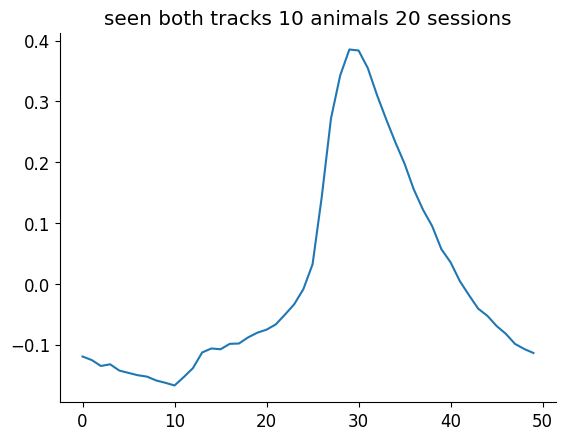

In [ ]:
seen_both_tracks_list = [15, 30, 16, 31, 21, 35, 22, 36, 24, 38, 26, 40, 28, 41, 20, 34, 23, 37, 25, 39]

cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in seen_both_tracks_list:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("seen both tracks 10 animals 20 sessions")


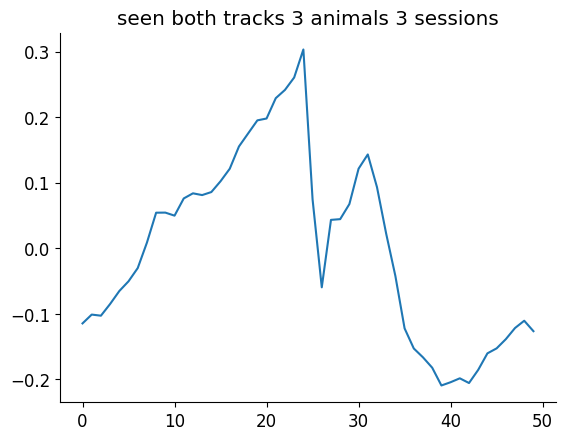

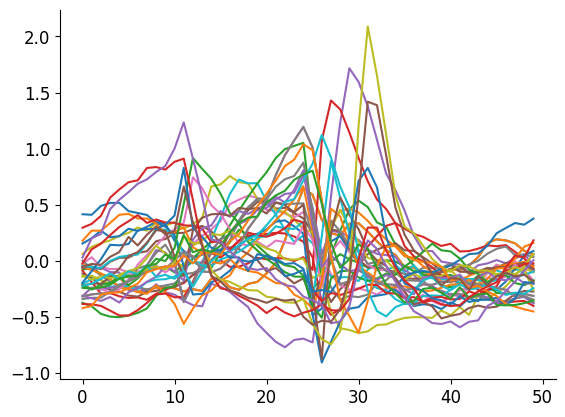

In [ ]:
seen_b1_no_a1 = [29, 32, 33]

cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in seen_b1_no_a1:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("seen both tracks 3 animals 3 sessions")
plt.show()

for i in range(len(cell_list)):
    plt.plot(cell_list[i])
plt.show()

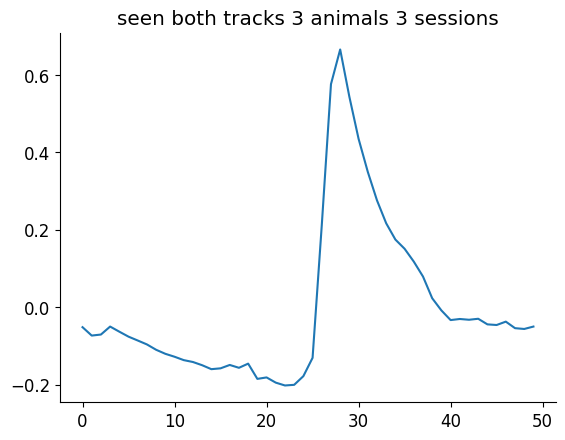

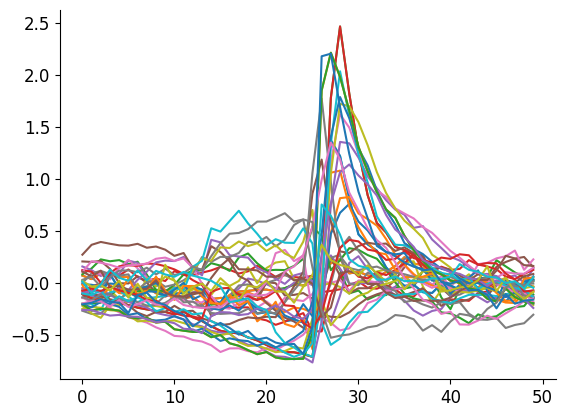

In [ ]:
seen_A1_no_B1 = [17, 18, 19, 27]

cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in seen_A1_no_B1:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("seen both tracks 3 animals 3 sessions")
plt.show()

for i in range(len(cell_list)):
    plt.plot(cell_list[i])
plt.show()

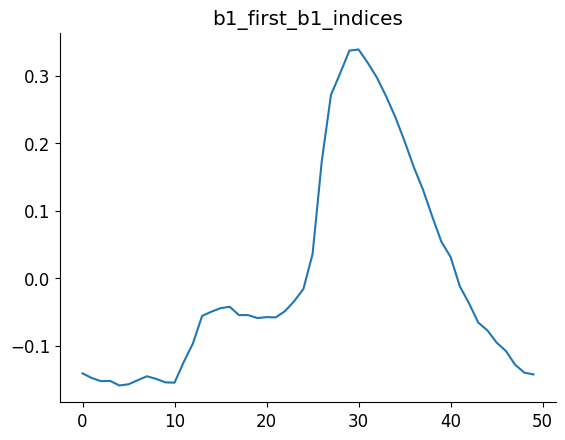

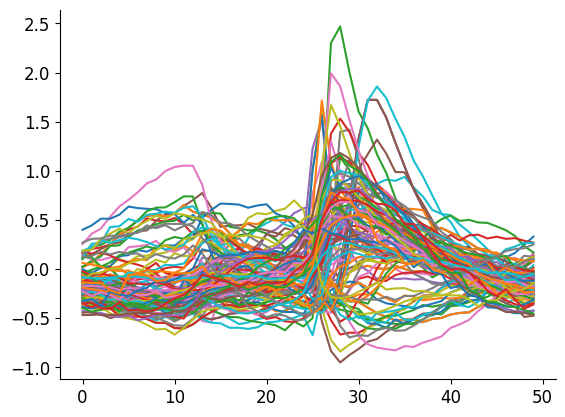

In [ ]:
b1_first_b1_indices = [30, 31, 38, 40, 41, 37, 39]


cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in b1_first_b1_indices:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("b1_first_b1_indices")
plt.show()

for i in range(len(cell_list)):
    plt.plot(cell_list[i])
plt.show()

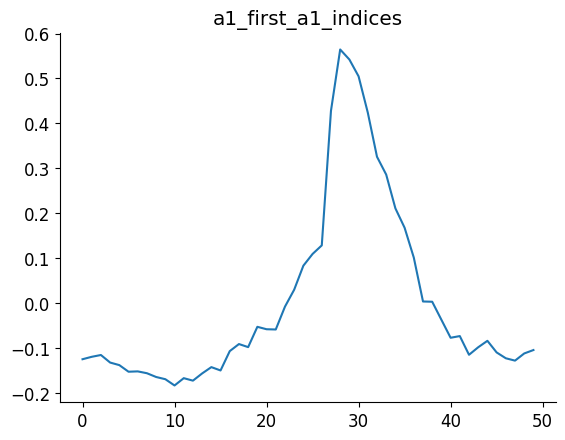

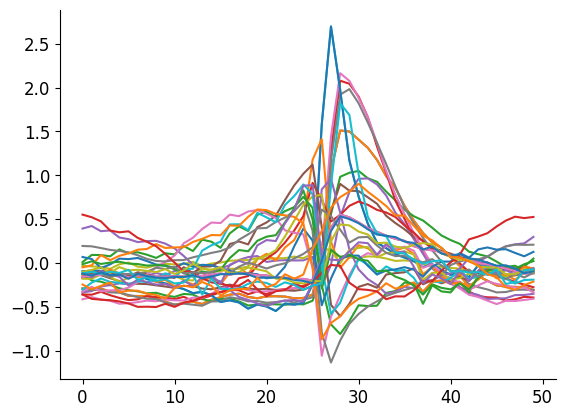

In [ ]:
a1_first_a1_indices = [21, 22, 20]


cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in a1_first_a1_indices:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("a1_first_a1_indices")
plt.show()

for i in range(len(cell_list)):
    plt.plot(cell_list[i])
plt.show()

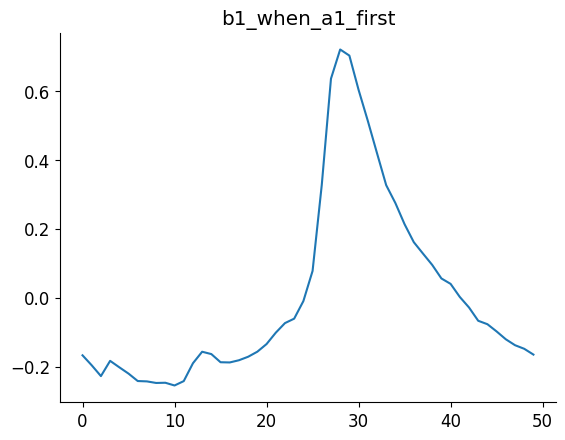

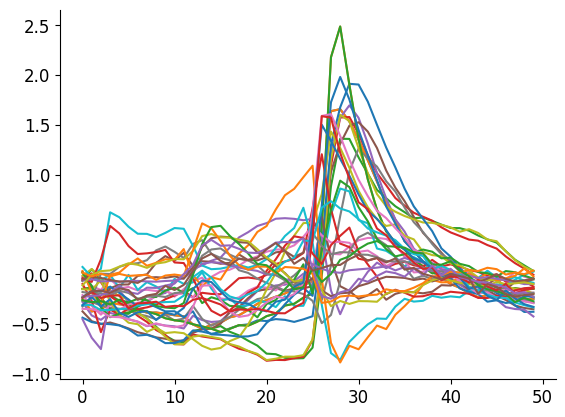

In [ ]:
b1_when_a1_first = [35, 36, 34]
cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in b1_when_a1_first:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("b1_when_a1_first")
plt.show()

for i in range(len(cell_list)):
    plt.plot(cell_list[i])
plt.show()

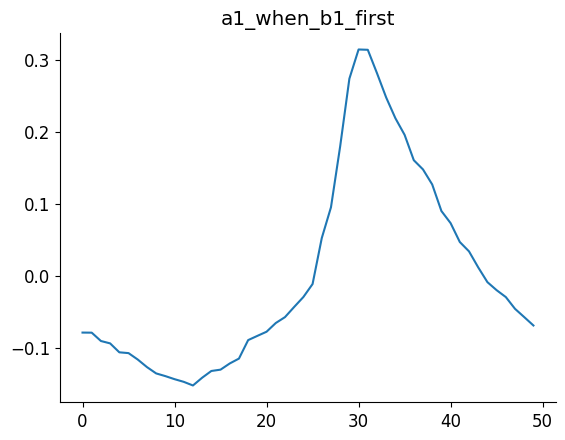

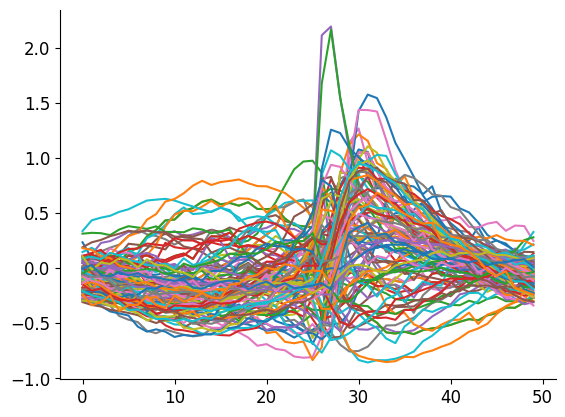

In [ ]:
a1_when_b1_first = [15, 16, 24, 26, 28, 23, 25]
cell_list = []
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx in a1_when_b1_first:
        for cell in residual_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(residual_activity_dict_NDNF_newest[animal][cell], axis=1))

cell_array = np.array(cell_list)
mean_cell_array = np.mean(cell_array, axis=0)


plt.plot(mean_cell_array) 
plt.title("a1_when_b1_first")
plt.show()

for i in range(len(cell_list)):
    plt.plot(cell_list[i])
plt.show()

In [ ]:
import h5py
import os

file_path = '/Users/michaelfinch/CA1-interneuron-GLM'
filename = "NDNF_E0A1B1_251107"
filepath = os.path.join(file_path, "datasets", filename + ".mat")

with h5py.File(filepath, 'r') as f:
    print("ROOT KEYS:", list(f.keys()))
    animals = f['animals']
    sessions = f['sessions']
    print("animals type:", type(animals))
    print("sessions type:", type(sessions))

    if isinstance(animals, h5py.Group):
        print("animals subgroup keys:", list(animals.keys()))
    else:
        print("animals shape:", animals.shape, "dtype:", animals.dtype)

    if isinstance(sessions, h5py.Group):
        print("sessions subgroup keys:", list(sessions.keys()))
    else:
        print("sessions shape:", sessions.shape, "dtype:", sessions.dtype)


ROOT KEYS: ['#refs#', 'animals', 'sessions']
animals type: <class 'h5py._hl.group.Group'>
sessions type: <class 'h5py._hl.dataset.Dataset'>
animals subgroup keys: ['L', 'Light', 'R', 'Running', 'ShiftL', 'ShiftLight', 'ShiftR', 'ShiftR_zscore', 'ShiftRunning', 'ShiftV', 'V']
sessions shape: (2, 42) dtype: object


In [ ]:
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E0A1B1_251107", new_NDNF=True, use_final=True)


fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

ramdom_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if idx < 15:
        ramdom_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 14 < idx < 29:
        print(animal)
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

cued_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if idx > 28:
        cued_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]


cued_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx > 28:
        cued_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]


fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]

animal_16
animal_17
animal_18
animal_19
animal_20
animal_21
animal_22
animal_23
animal_24
animal_25
animal_26
animal_27
animal_28
animal_29


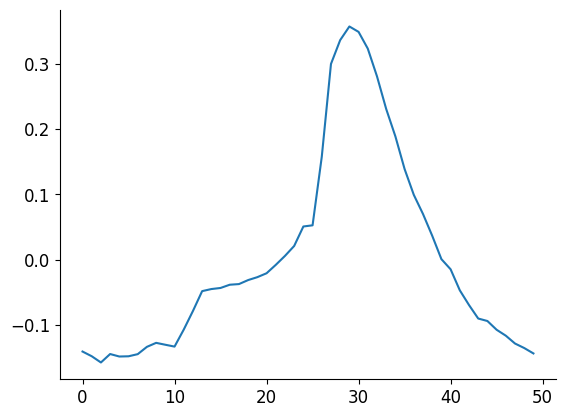

In [ ]:
fixed_list = []
for animal in cued_residual_activity_dict_NDNF_newest:
    for cell in cued_residual_activity_dict_NDNF_newest[animal]:
        fixed_list.append(np.mean(cued_residual_activity_dict_NDNF_newest[animal][cell], axis=1))


fixed_array = np.array(fixed_list)
plt.plot(np.mean(fixed_array, axis=0))

In [ ]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_reassign_models_NDNF.pkl', 'rb') as f:
    fixed_kmean_dict_final_x00 = pickle.load(f)

In [ ]:
def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict

In [ ]:
    if use_new_data:

        if use_fixed_track:
            with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_contig_models_NDNF.pkl', 'rb') as f:
                contig_data_dict = pickle.load(f)

        else:
            with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_cued_contig_models_NDNF.pkl', 'rb') as f:
                contig_data_dict = pickle.load(f)
            

        

    else:
        mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell'
        data_dict = get_model_data_per_cell(mse_dir)


        contig_data_dict = {20: {}}
        for idx, animal in enumerate(data_dict[20]):
            if use_fixed_track:
                if first_an_idx<idx<last_an_idx:
                    
                    contig_data_dict[20][animal-(first_an_idx+1)] = data_dict[20][animal]
            else:
                if idx>last_an_idx-1:
                    contig_data_dict[20][animal-(last_an_idx)] = data_dict[20][animal]


    print(f"contig_data_dict[20].keys() {contig_data_dict[20].keys()}")

    cp_dict_NDNF = get_cp_dict(contig_data_dict)

    print(f"cp_dict_NDNF.keys() {cp_dict_NDNF.keys()}")

In [ ]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_contig_models_NDNF.pkl', 'rb') as f:
    fixed_contig_dict_final_x00 = pickle.load(f)

fixed_contig_dict_final_x00

{20: {0: {0: [SliceTCA(
      (vectors): ModuleList(
        (0): ParameterList(
            (0): Parameter containing: [torch.float32 of size 0x217]
            (1): Parameter containing: [torch.float32 of size 0x1x50]
        )
        (1): ParameterList(
            (0): Parameter containing: [torch.float32 of size 0x1]
            (1): Parameter containing: [torch.float32 of size 0x217x50]
        )
        (2): ParameterList(
            (0): Parameter containing: [torch.float32 of size 20x50]
            (1): Parameter containing: [torch.float32 of size 20x217x1]
        )
      )
    ),
    {'cell_0': {'labels_dict': {'clusters_chosen_2': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              0, 0, 0, 0, 0, 0, 0

In [ ]:

def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
    min_val = 10000

    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data = fixed_activity_dict_NDNF_newest[animal][cell]
            if data.shape[1] < min_val:
                min_val = data.shape[1]

    data_truncated_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            data_truncated_list.append(data_truncated)


    data_truncated_array = np.array(data_truncated_list)

    return data_truncated_array

def get_the_tca_model(fixed_residual_activity_dict, components=None):
    data_truncated_array = get_truncated_to_min_data_array(fixed_residual_activity_dict)
    example_cell_tensor = torch.from_numpy(data_truncated_array)
    example_cell_tensor = example_cell_tensor.permute(2,0,1)

        
    components, model_20 = slicetca.decompose(example_cell_tensor,
                                                number_components=components, # (trials, neurons, time bins)
                                                positive=False,learning_rate=1*10**-2, min_std=10**-5, max_iter=4000, iter_std=1000,seed=0)

    plt.plot(model_20.losses, color='k')
    plt.show()

    return model_20

Loss: 0.4722530174845627 : 100%|██████████| 4000/4000 [07:39<00:00,  8.70it/s] 


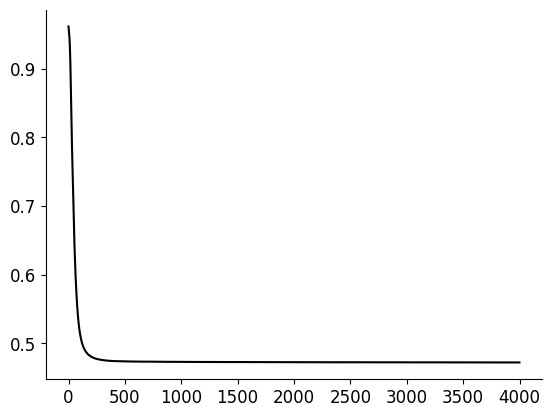

In [ ]:
model_20_NDNF_resid_0x0_cue_new_data = get_the_tca_model(cued_residual_activity_dict_NDNF_newest, components=(0,20,0))


In [ ]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_cued_reassign_models_NDNF.pkl', 'rb') as f:
    cued_kmean_dict_final_x00 = pickle.load(f)

data_dict = fixed_kmean_dict_final_x00[20][0][0][1]["cell_0"]["labels_dict"]

In [ ]:
real_data = cued_residual_activity_dict_NDNF_newest["animal_30"]["cell_1"]

In [ ]:
def save_the_dict(save_path, cued_residual_activity_dict_NDNF_newest):
    with open(save_path, 'rb') as f:
        cued_kmean_dict_final_x00 = pickle.load(f)

    for idx, animal in enumerate(cued_residual_activity_dict_NDNF_newest):
        for idt, cell in enumerate(cued_residual_activity_dict_NDNF_newest[animal]):
            data_dict = cued_kmean_dict_final_x00[20][idx][idt][1][f"cell_{idt}"]["labels_dict"]
            real_data = cued_residual_activity_dict_NDNF_newest[animal][cell]
            MSE_dict = {}
            for clusters_chosen in data_dict:
                data_array = data_dict[clusters_chosen]
                unique_labels = np.unique(data_array)
                empty_mse_data_array = np.empty((real_data.shape))
                for unique_label in unique_labels:
                    indices_label = np.where(data_array==unique_label)[0]
                    data_slice = real_data[:,indices_label]
                    mean_data_slice = np.mean(data_slice, axis=1)
                    for i in indices_label:
                        empty_mse_data_array[:,i] = mean_data_slice

                MSE = np.mean(np.square(empty_mse_data_array-real_data))

                MSE_dict[clusters_chosen] = MSE
            cued_kmean_dict_final_x00[20][idx][idt][1][f"cell_{idt}"]["MSE_dict"] = MSE_dict

    return cued_kmean_dict_final_x00

save_path_cued = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_cued_reassign_models_NDNF.pkl'
cued_kmean_dict_final_x00 = save_the_dict(save_path_cued, cued_residual_activity_dict_NDNF_newest)

In [ ]:
with open(save_path_cued, 'wb') as f:
   pickle.dump(cued_kmean_dict_final_x00,f)

In [ ]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/model_20_NDNF_resid_0x0_cue_new_data.pkl', 'wb') as f:
    pickle.dump(model_20_NDNF_resid_0x0_cue_new_data, f)
    


In [ ]:
save_path_fixed = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_reassign_models_NDNF.pkl'
fixed_kmean_dict_final_x00 = save_the_dict(save_path_fixed, fixed_residual_activity_dict_NDNF_newest)

with open(save_path_fixed, 'wb') as f:
    pickle.dump(fixed_kmean_dict_final_x00, f)

In [ ]:
fixed_residual_activity_dict_NDNF_newest.keys()

dict_keys(['animal_16', 'animal_17', 'animal_18', 'animal_19', 'animal_20', 'animal_21', 'animal_22', 'animal_23', 'animal_24', 'animal_25', 'animal_26', 'animal_27', 'animal_28', 'animal_29'])

  0%|          | 0/4000 [00:00<?, ?it/s]

Loss: 0.4666784795464152 : 100%|██████████| 4000/4000 [02:13<00:00, 29.88it/s] 


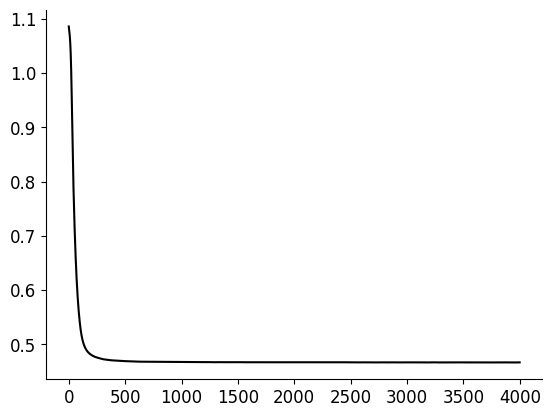

In [ ]:
model_20_NDNF_resid_0x0_fixed_new_data = get_the_tca_model(fixed_residual_activity_dict_NDNF_newest, components=(0,20,0))

Loss: 0.6199501413801396 : 100%|██████████| 4000/4000 [08:47<00:00,  7.59it/s]


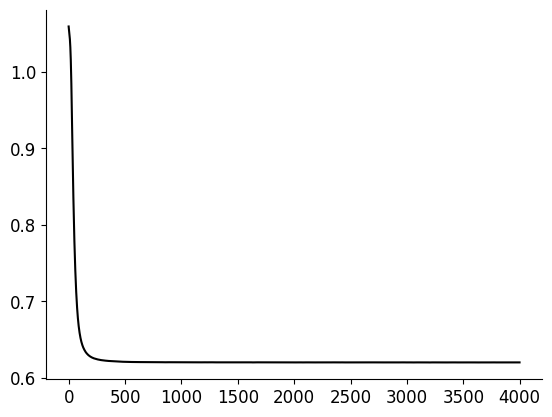

In [ ]:
model_20_NDNF_resid_0x0_all_new_data = get_the_tca_model(residual_activity_dict_NDNF_newest, components=(0,20,0))

In [ ]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/model_20_NDNF_resid_0x0_all_new_data.pkl', 'wb') as f:
    pickle.dump(model_20_NDNF_resid_0x0_all_new_data, f)
    

In [ ]:
def get_labels_all_different_Ks_single(model_20_NDNF_resid, which_vectors: int):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    w1 = model_20_NDNF_resid.vectors[which_vectors][0]
    f1 = model_20_NDNF_resid.vectors[which_vectors][1]
    F = f1.detach().cpu().numpy()   # (latents, cells, pos) = (20, 115, 50)
    W = w1.detach().cpu().numpy()   # (latents, trials) = (20, 100)

    print(f"F.shape {F.shape}  W.shape {W.shape}")

    # Build X so rows = cells (115)
    if which_vectors == 0:
        # Use latent×pos per cell, flattened: (115, 20*50)
        X = np.moveaxis(F, 1, 0)              # (cells=115, latents=20, pos=50)
        X = X.reshape(X.shape[0], -1)         # (115, 1000)
        print("X shape (latent×pos flat):", X.shape)

    elif which_vectors == 1:
        X = W.T  # (115, 20) mean over pos
        print("X shape (mean over pos):", X.shape)

    else:
        X = np.moveaxis(F, 2, 0)     # -> (cells=115, latents=20, trials=100)
        X = X.reshape(X.shape[0], -1)  # -> (115, 20*100) = (115, 2000)
        print(X.shape)  # (115, 2000)

    # Standardize then KMeans over K=1..10
    Xz = StandardScaler().fit_transform(X)
    labels_cells_dict_all_K = {K: KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(Xz) for K in range(1, 11)}
    return labels_cells_dict_all_K


In [ ]:
labels_cells_dict_all_K_NDNF_fixed = get_labels_all_different_Ks_single(model_20_NDNF_resid_0x0_fixed_new_data, which_vectors=1)


cell_type_labels = labels_cells_dict_all_K_NDNF_fixed[2]

cells_group_0 = np.where(cell_type_labels==0)[0]
cells_group_1 = np.where(cell_type_labels==1)[0]

AttributeError: 'NoneType' object has no attribute 'vectors'

In [ ]:
weight

Parameter containing:
tensor([[ 0.0743,  0.0088,  0.0819,  ...,  0.0206,  0.0179, -0.0179],
        [ 0.0210, -0.0843, -0.0275,  ...,  0.0121, -0.1134,  0.0025],
        [ 0.0774,  0.0099, -0.0213,  ..., -0.0252, -0.0681,  0.0279],
        ...,
        [-0.0409,  0.0809, -0.0410,  ..., -0.0565,  0.0760,  0.0202],
        [ 0.0159, -0.0172,  0.0187,  ..., -0.0245,  0.0271, -0.0083],
        [-0.0012, -0.0690, -0.0816,  ..., -0.0658, -0.0712, -0.1061]],
       requires_grad=True)

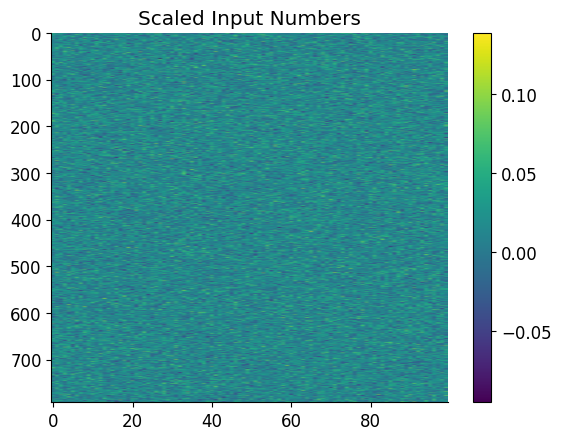

In [ ]:
mean = 0.4 * 1/(np.sqrt(792))
std=0.7 *1/(np.sqrt(792))

rng = np.random.default_rng(42)

samples = rng.normal(loc=mean, scale=std, size=(792, 100))

plt.imshow(samples, aspect='auto')
plt.title("Scaled Input Numbers")
plt.colorbar()

In [ ]:
1/np.sqrt(792)

0.035533452725935076

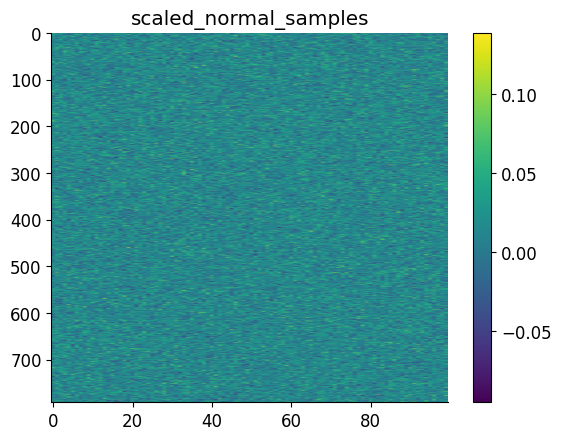

In [ ]:

mean = 0.4
std=0.7

rng = np.random.default_rng(42)

samples = rng.normal(loc=mean, scale=std, size=(792, 100))

plt.imshow(samples, aspect='auto')
plt.colorbar()

scaled_normal_samples = samples * 1/(np.sqrt(792))
plt.imshow(scaled_normal_samples, aspect='auto')
plt.title("scaled_normal_samples")
plt.colorbar()

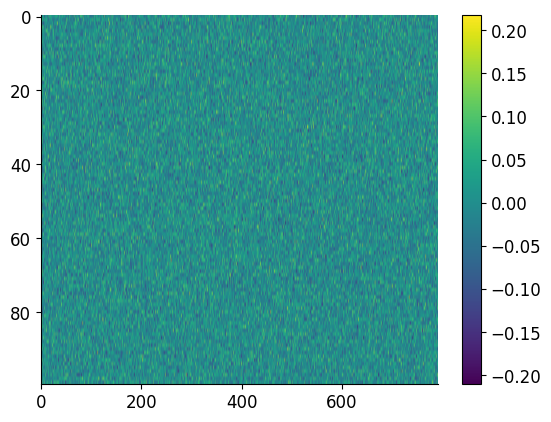

In [ ]:
import torch

all_ones = np.ones((100,792))

# Create a generator on the CPU
g_cpu = torch.Generator(device='cpu')

# Optional: seed the generator for reproducible results
g_cpu.manual_seed(42)

weight = torch.nn.init.kaiming_normal_(torch.from_numpy(all_ones), mode="fan_in", nonlinearity="relu", generator=g_cpu) ### needs to be 100,792
weight_numpy = weight.detach()
plt.imshow(weight_numpy, aspect='auto')
plt.colorbar()

343.0


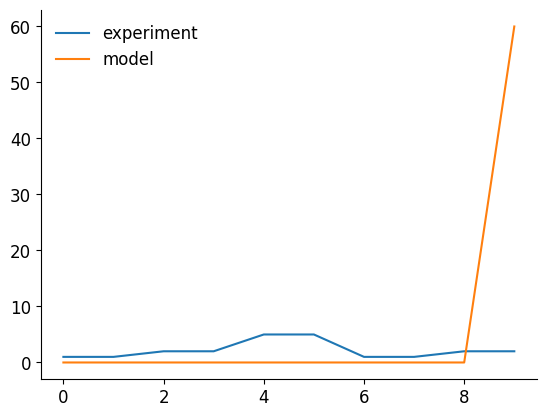

In [ ]:
overrep = np.array([0.01, 0.01, 0.02, 0.02, 0.05, 0.05, 0.01, 0.01, 0.02, 0.02])*100
model= np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6]) *100

print(np.mean(np.square(overrep-model)))

plt.plot(overrep, label='experiment')
plt.plot(model, label='model')
plt.legend()